## Time Travael 
We have seen hwo breakpoints can stop the graph at specific nodes or allow the graph to dynamically interrupt itself tehn we show how to proceed with human approval or directly edit the graph state with human feedback

### Goal 
Now tels show how LG [suppots Deugging](https://docs.langchain.com/oss/python/langgraph/use-time-travel) by viewign, replaing and even forking from past states - This is called as `time travel`

In [1]:
from warnings import filterwarnings
filterwarnings('ignore')

import os
from dotenv import load_dotenv
from langchain_aws import ChatBedrockConverse
load_dotenv()

os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ["LANGCHAIN_TRACING_V2"] = "true" # Enable LangSmith tracing
os.environ['LANGSMITH_PROJECT'] = 'LangGraphTraining' 

model = ChatBedrockConverse(model= "us.anthropic.claude-sonnet-4-6",)

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
from langgraph.graph import START, END, StateGraph, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import tools_condition, ToolNode

from langchain_core.messages import HumanMessage, SystemMessage

c:\Data\Codes\AgenticAITraining\Lanchain_LangGraph\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [3]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a by b.

    Args:
        a: first int
        b: second int
    """
    if b == 0:
        raise ValueError('Can\'t Divide with 0')
    return a / b

In [4]:
tools = [add, multiply, divide]
llm_with_tools = model.bind_tools(tools)

In [5]:
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs using the provided tools.")

def assistant(state: MessagesState):
    return {'messages': [llm_with_tools.invoke([sys_msg] + state['messages'])]}

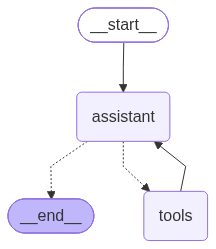

In [6]:
builder = StateGraph(MessagesState)
builder.add_node('assistant', assistant)
builder.add_node('tools', ToolNode(tools))

builder.add_edge(START, 'assistant')
builder.add_conditional_edges('assistant', tools_condition)
builder.add_edge('tools', 'assistant')

graph = builder.compile(checkpointer = MemorySaver())
graph

In [7]:
initial_input = {'messages': HumanMessage('multiply 3 with 5')}
thread = {'configurable': {'thread_id': '1'}}

for event in graph.stream(initial_input, thread, stream_mode='values'):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

multiply 3 with 5
================================== Ai Message ==================================

[{'type': 'text', 'text': "I'll multiply 3 and 5 right away!"}, {'type': 'tool_use', 'name': 'multiply', 'input': {'a': 3, 'b': 5}, 'id': 'tooluse_JrZ4qvNdo7Cg35VLHhQc8x'}]
Tool Calls:
  multiply (tooluse_JrZ4qvNdo7Cg35VLHhQc8x)
 Call ID: tooluse_JrZ4qvNdo7Cg35VLHhQc8x
  Args:
    a: 3
    b: 5
================================= Tool Message =================================
Name: multiply

15
================================== Ai Message ==================================

The result of multiplying **3** with **5** is **15**! 🎉


We can use `get_state` to look at the current state of our graph, given the `thread`

In [8]:
graph.get_state(thread)

StateSnapshot(values={'messages': [HumanMessage(content='multiply 3 with 5', additional_kwargs={}, response_metadata={}, id='367af8d7-7a79-40b3-bf0b-5f19a85385fc'), AIMessage(content=[{'type': 'text', 'text': "I'll multiply 3 and 5 right away!"}, {'type': 'tool_use', 'name': 'multiply', 'input': {'a': 3, 'b': 5}, 'id': 'tooluse_JrZ4qvNdo7Cg35VLHhQc8x'}], additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '07ada9e2-34ff-4390-a801-021ddc65a6dc', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Fri, 14 Aug 2026 06:53:58 GMT', 'content-type': 'application/json', 'content-length': '465', 'connection': 'keep-alive', 'x-amzn-requestid': '07ada9e2-34ff-4390-a801-021ddc65a6dc'}, 'RetryAttempts': 0}, 'stopReason': 'tool_use', 'metrics': {'latencyMs': [1368]}, 'model_provider': 'bedrock_converse', 'model_name': 'us.anthropic.claude-sonnet-4-6'}, id='lc_run--019fff0c-7626-7333-aba9-495b7ea55936-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 5}, 'id': 'tooluse_JrZ

In [10]:
all_state = [s for s in graph.get_state_history(thread)]
all_state

[StateSnapshot(values={'messages': [HumanMessage(content='multiply 3 with 5', additional_kwargs={}, response_metadata={}, id='367af8d7-7a79-40b3-bf0b-5f19a85385fc'), AIMessage(content=[{'type': 'text', 'text': "I'll multiply 3 and 5 right away!"}, {'type': 'tool_use', 'name': 'multiply', 'input': {'a': 3, 'b': 5}, 'id': 'tooluse_JrZ4qvNdo7Cg35VLHhQc8x'}], additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '07ada9e2-34ff-4390-a801-021ddc65a6dc', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Fri, 14 Aug 2026 06:53:58 GMT', 'content-type': 'application/json', 'content-length': '465', 'connection': 'keep-alive', 'x-amzn-requestid': '07ada9e2-34ff-4390-a801-021ddc65a6dc'}, 'RetryAttempts': 0}, 'stopReason': 'tool_use', 'metrics': {'latencyMs': [1368]}, 'model_provider': 'bedrock_converse', 'model_name': 'us.anthropic.claude-sonnet-4-6'}, id='lc_run--019fff0c-7626-7333-aba9-495b7ea55936-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 5}, 'id': 'tooluse_Jr

In [11]:
all_state[-2]

StateSnapshot(values={'messages': [HumanMessage(content='multiply 3 with 5', additional_kwargs={}, response_metadata={}, id='367af8d7-7a79-40b3-bf0b-5f19a85385fc')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f197ace-a476-6f32-8000-3d675e37dc6b'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-08-14T06:53:54.591482+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f197ace-a470-6234-bfff-a32ea421a790'}}, tasks=(PregelTask(id='d5857d6c-d3fd-cf60-fffd-d1fc0a32169a', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result={'messages': [AIMessage(content=[{'type': 'text', 'text': "I'll multiply 3 and 5 right away!"}, {'type': 'tool_use', 'name': 'multiply', 'input': {'a': 3, 'b': 5}, 'id': 'tooluse_JrZ4qvNdo7Cg35VLHhQc8x'}], additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '07ada9e2-34ff

We can rerun our agent form any of the prior steps

Let's look back at the step that recieved thae human input

In [19]:
# replay = all_state[-2]
replay = all_state[-3]
replay

StateSnapshot(values={'messages': [HumanMessage(content='multiply 3 with 5', additional_kwargs={}, response_metadata={}, id='367af8d7-7a79-40b3-bf0b-5f19a85385fc'), AIMessage(content=[{'type': 'text', 'text': "I'll multiply 3 and 5 right away!"}, {'type': 'tool_use', 'name': 'multiply', 'input': {'a': 3, 'b': 5}, 'id': 'tooluse_JrZ4qvNdo7Cg35VLHhQc8x'}], additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '07ada9e2-34ff-4390-a801-021ddc65a6dc', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Fri, 14 Aug 2026 06:53:58 GMT', 'content-type': 'application/json', 'content-length': '465', 'connection': 'keep-alive', 'x-amzn-requestid': '07ada9e2-34ff-4390-a801-021ddc65a6dc'}, 'RetryAttempts': 0}, 'stopReason': 'tool_use', 'metrics': {'latencyMs': [1368]}, 'model_provider': 'bedrock_converse', 'model_name': 'us.anthropic.claude-sonnet-4-6'}, id='lc_run--019fff0c-7626-7333-aba9-495b7ea55936-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 5}, 'id': 'tooluse_JrZ

In [20]:
replay.values.get('messages', '')

[HumanMessage(content='multiply 3 with 5', additional_kwargs={}, response_metadata={}, id='367af8d7-7a79-40b3-bf0b-5f19a85385fc'),
 AIMessage(content=[{'type': 'text', 'text': "I'll multiply 3 and 5 right away!"}, {'type': 'tool_use', 'name': 'multiply', 'input': {'a': 3, 'b': 5}, 'id': 'tooluse_JrZ4qvNdo7Cg35VLHhQc8x'}], additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '07ada9e2-34ff-4390-a801-021ddc65a6dc', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Fri, 14 Aug 2026 06:53:58 GMT', 'content-type': 'application/json', 'content-length': '465', 'connection': 'keep-alive', 'x-amzn-requestid': '07ada9e2-34ff-4390-a801-021ddc65a6dc'}, 'RetryAttempts': 0}, 'stopReason': 'tool_use', 'metrics': {'latencyMs': [1368]}, 'model_provider': 'bedrock_converse', 'model_name': 'us.anthropic.claude-sonnet-4-6'}, id='lc_run--019fff0c-7626-7333-aba9-495b7ea55936-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 5}, 'id': 'tooluse_JrZ4qvNdo7Cg35VLHhQc8x', 'type': 'to

In [21]:
replay.next, replay.config

(('tools',),
 {'configurable': {'thread_id': '1',
   'checkpoint_ns': '',
   'checkpoint_id': '1f197ace-cb82-6edd-8001-a8adb329cd0c'}})

To replay from here, we simply passs the config back to the agent!!

The graph knows that this checkpoint is already execute, it Just Replays from this checkpoint. 

In [22]:
for event in graph.stream(None, replay.config, stream_mode = 'values'):
    event['messages'][-1].pretty_print()

================================== Ai Message ==================================

[{'type': 'text', 'text': "I'll multiply 3 and 5 right away!"}, {'type': 'tool_use', 'name': 'multiply', 'input': {'a': 3, 'b': 5}, 'id': 'tooluse_JrZ4qvNdo7Cg35VLHhQc8x'}]
Tool Calls:
  multiply (tooluse_JrZ4qvNdo7Cg35VLHhQc8x)
 Call ID: tooluse_JrZ4qvNdo7Cg35VLHhQc8x
  Args:
    a: 3
    b: 5
================================= Tool Message =================================
Name: multiply

15
================================== Ai Message ==================================

The result of multiplying **3** by **5** is **15**! 🎉


### FORKING

What if we want to run from that same step, but with different input. This is forking. 

The Previous steps remains same and then create a copy for the new one.

In [23]:
fork = all_state[-2]
fork.values['messages']

[HumanMessage(content='multiply 3 with 5', additional_kwargs={}, response_metadata={}, id='367af8d7-7a79-40b3-bf0b-5f19a85385fc')]

In [26]:
fork.values['messages'][0].id, fork.next, fork.config

('367af8d7-7a79-40b3-bf0b-5f19a85385fc',
 ('assistant',),
 {'configurable': {'thread_id': '1',
   'checkpoint_ns': '',
   'checkpoint_id': '1f197ace-a476-6f32-8000-3d675e37dc6b'}})

Now we modify the state at this checkpoint. 
We can just run `update_state` with the `checkpoint_id`.

Remember how out reducer on `messages` work: It will append unless we supply a messgeId, We supply the messsageid the messsage is overwritten. 

To overwrite we just supply messageID

In [28]:
fork_config = graph.update_state(
    fork.config,
    {
        'messages': [HumanMessage('Add 3 and 9', id = fork.values['messages'][0].id)]
    }
)

fork_config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f197bb0-522d-66d1-8001-15a1fe030db0'}}

This creates a new, forked checkpoint.
 
But, the metadata - e.g., where to go next - is perserved! 

We can see the current state of our agent has been updated with our fork.

In [29]:
all_states = [state for state in graph.get_state_history(thread) ]
all_states

[StateSnapshot(values={'messages': [HumanMessage(content='Add 3 and 9', additional_kwargs={}, response_metadata={}, id='367af8d7-7a79-40b3-bf0b-5f19a85385fc')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f197bb0-522d-66d1-8001-15a1fe030db0'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-08-14T08:34:52.604357+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f197ace-a476-6f32-8000-3d675e37dc6b'}}, tasks=(PregelTask(id='665a7107-a4ae-52b1-885c-38c9728f5a5f', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'messages': [HumanMessage(content='Add 3 and 9', additional_kwargs={}, response_metadata={}, id='367af8d7-7a79-40b3-bf0b-5f19a85385fc')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f197bb0

In [32]:
all_states[0].values["messages"], all_states[0].next

([HumanMessage(content='Add 3 and 9', additional_kwargs={}, response_metadata={}, id='367af8d7-7a79-40b3-bf0b-5f19a85385fc')],
 ('assistant',))

In [33]:
graph.get_state(thread)

StateSnapshot(values={'messages': [HumanMessage(content='Add 3 and 9', additional_kwargs={}, response_metadata={}, id='367af8d7-7a79-40b3-bf0b-5f19a85385fc')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f197bb0-522d-66d1-8001-15a1fe030db0'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-08-14T08:34:52.604357+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f197ace-a476-6f32-8000-3d675e37dc6b'}}, tasks=(PregelTask(id='665a7107-a4ae-52b1-885c-38c9728f5a5f', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

Now we stream the graph knows thsi checkpoint has never been executed, so the graph runs

In [34]:
for event in graph.stream(None, fork_config, stream_mode='values'):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Add 3 and 9
================================== Ai Message ==================================

[{'type': 'tool_use', 'name': 'add', 'input': {'a': 3, 'b': 9}, 'id': 'tooluse_CwunO8t2T47P4L0FeYlzMK'}]
Tool Calls:
  add (tooluse_CwunO8t2T47P4L0FeYlzMK)
 Call ID: tooluse_CwunO8t2T47P4L0FeYlzMK
  Args:
    a: 3
    b: 9
================================= Tool Message =================================
Name: add

12
================================== Ai Message ==================================

The sum of 3 and 9 is **12**!


In [36]:
graph.get_state(thread).values['messages']

[HumanMessage(content='Add 3 and 9', additional_kwargs={}, response_metadata={}, id='367af8d7-7a79-40b3-bf0b-5f19a85385fc'),
 AIMessage(content=[{'type': 'tool_use', 'name': 'add', 'input': {'a': 3, 'b': 9}, 'id': 'tooluse_CwunO8t2T47P4L0FeYlzMK'}], additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '19d40daf-b69e-4789-9415-58f571da8b8b', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Fri, 14 Aug 2026 08:38:17 GMT', 'content-type': 'application/json', 'content-length': '415', 'connection': 'keep-alive', 'x-amzn-requestid': '19d40daf-b69e-4789-9415-58f571da8b8b'}, 'RetryAttempts': 0}, 'stopReason': 'tool_use', 'metrics': {'latencyMs': [1442]}, 'model_provider': 'bedrock_converse', 'model_name': 'us.anthropic.claude-sonnet-4-6'}, id='lc_run--019fff6c-0134-7a83-a97c-0425a5db78e9-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 9}, 'id': 'tooluse_CwunO8t2T47P4L0FeYlzMK', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 766, 'output